<a href="https://colab.research.google.com/github/Kristinna25/bigdata-economy-mentalhealth/blob/main/bigdata_economic_mentalhealth.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 경제 지표와 정신건강 검색량 분석(Economic and Mental Health Trends)

한국의 실업률, 소비자물가지수(CPI)와  
구글 트렌드에 있는 정신건강 관련 키워드관련 키워드(스트레스, 우울증, 불안, 불면증, 외로움) 검색량을 분석했다.
데이터 전처리,
시계열 시계열 시각화,
상관계수 히트맵,
Plotly Animation ,
ARIMA

In [1]:
# 폰트 설치
!apt-get -qq -y install fonts-nanum

import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np
import seaborn as sns

# NanumGothic port directory
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
font_prop = fm.FontProperties(fname=font_path, size=14)

# 마이너스 깨짐 방지 + remove cache
mpl.rcParams["axes.unicode_minus"] = False
!rm -rf /root/.cache/matplotlib

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 100)

Selecting previously unselected package fonts-nanum.
(Reading database ... 121713 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


## 데이터 불러오기

사용한 데이터

- `economy_activity.csv`: 경제활동인구, 실업률
- `cpi.csv`: 소비자물가지수(CPI)
- `mental_trends.csv`: 구글 트렌드에서 가져온 정신건강 관련 키워드 검색량

인코딩을 간단히 확인한 뒤, `utf-8-sig`로 데이터를 불러왔다.  
구글 트렌드 데이터는 상단에 메타데이터가 있어서 `skiprows=2`를 사용했다.


In [2]:
# 인코딩 때문에 에러 나는 경우가 있어서 먼저 확인

# file loading
files = {
    "경제활동인구": "/content/economy_activity.csv",
    "소비자물가지수": "/content/cpi.csv",
    "구글트렌드": "/content/mental_trends.csv"
}

encodings = ["utf-8-sig", "cp949", "euc-kr"]

# 파일마다 어떤 인코딩이 되는지 테스트
for name, path in files.items():
    print(f"## \n{name} 파일 테스트")
    for enc in encodings:
        try:
            pd.read_csv(path, encoding=enc, nrows=3)
            print(f"성공: {enc}")
        except UnicodeDecodeError:
            print(f"실패: {enc}")

# 실제로 사용할 로딩
eco_raw   = pd.read_csv("/content/economy_activity.csv", encoding="utf-8-sig")
cpi_raw   = pd.read_csv("/content/cpi.csv", encoding="utf-8-sig")

# 구글 트렌드는 앞부분 메타데이터 2줄 제거
trend_raw = pd.read_csv("/content/mental_trends.csv", encoding="utf-8-sig", skiprows=2)

eco_raw.head(), cpi_raw.head(), trend_raw.head()

## 
경제활동인구 파일 테스트
성공: utf-8-sig
실패: cp949
실패: euc-kr
## 
소비자물가지수 파일 테스트
성공: utf-8-sig
실패: cp949
실패: euc-kr
## 
구글트렌드 파일 테스트
성공: utf-8-sig
실패: cp949
실패: euc-kr


(             통계표   계정항목  구분코드 단위   변환  2019/01  2019/02  2019/03  2019/04  \
 0  8.6.2. 경제활동인구    실업률  계절조정  %  원자료      3.9      3.9      3.8      4.1   
 
    2019/05  2019/06  2019/07  2019/08  2019/09  2019/10  2019/11  2019/12  \
 0      3.8      3.9      4.0      3.6      3.6      3.5      3.6      3.5   
 
    2020/01  2020/02  2020/03  2020/04  2020/05  2020/06  2020/07  2020/08  \
 0      3.5      3.4      3.8      3.9      4.3      4.2      4.2      3.7   
 
    2020/09  2020/10  2020/11  2020/12  2021/01  2021/02  2021/03  2021/04  \
 0      4.1      4.2      4.1      4.2      4.7      4.1      3.9      3.8   
 
    2021/05  2021/06  2021/07  2021/08  2021/09  2021/10  2021/11  2021/12  \
 0      3.8      3.7      3.3      3.2      3.1      3.2      3.1      3.5   
 
    2022/01  2022/02  2022/03  2022/04  2022/05  2022/06  2022/07  2022/08  \
 0      3.3      2.8      2.8      2.8      2.9      2.9      3.0      2.6   
 
    2022/09  2022/10  2022/11  2022/12  2023/01  202

## 실업률 데이터 전처리

경제활동인구 데이터에서 '실업률'이 포함된 행만 골라서 사용했다.  
연·월이 열로 들어가 있는 wide 형식을 `melt`로 long 형식으로 바꾸고,  날짜는 `datetime`으로 변환했다.
실업률 값의 결측치는 평균값으로 채웠다.

In [3]:
# ECO 데이터에서 월 형식 컬럼만 뽑기
eco_date_cols = [c for c in eco_raw.columns if "/" in c]

# 실업률 관련 행만 선택
eco_pick = eco_raw.loc[
    eco_raw['계정항목'].astype(str).str.contains("실업률")
].copy()

# wide 형태를 long 형태로 변환
eco_long = eco_pick.melt(
    id_vars=['계정항목'],
    value_vars=eco_date_cols,
    var_name="date",
    value_name="실업률"
)

# 날짜 컬럼 변환
eco_long['date'] = pd.to_datetime(
    eco_long['date'],
    format='%Y/%m',
    errors='coerce'
)
eco_long = eco_long.dropna(subset=['date'])

# 실업률 데이터 숫자로 바꾸고 NaN 처리
eco_long['실업률'] = pd.to_numeric(
    eco_long['실업률'],
    errors='coerce'
)
eco_long['실업률'] = eco_long['실업률'].fillna(
    eco_long['실업률'].mean()
)

# 분석에 사용할 형태로 정리
eco = (
    eco_long[['date', '실업률']]
    .sort_values('date')
    .reset_index(drop=True)
)

display(eco.head())
display(eco.tail())


,date,실업률
0,2019-01-01,3.9
1,2019-02-01,3.9
2,2019-03-01,3.8
3,2019-04-01,4.1
4,2019-05-01,3.8


,date,실업률
67,2024-08-01,2.5
68,2024-09-01,2.5
69,2024-10-01,2.7
70,2024-11-01,2.7
71,2024-12-01,3.7


## 소비자물가지수(CPI) 전처리

CPI 데이터에서는 '소비자물가지수'가 포함된 행을 골라 사용했다.  
마찬가지로 wide 형식을 long 형식으로 바꾸고, 날짜와 수치를 정리했다.  
CPI의 결측치는 평균값으로 채웠다.

In [4]:
# CPI: 소비자물가지수만 추출

cpi_date_cols = [c for c in cpi_raw.columns if "/" in c]
label_cols = ["통계표", "계정항목", "단위", "가중치", "변환"]
label_cols = [c for c in label_cols if c in cpi_raw.columns]

print("NaN count (CPI date columns):", cpi_raw[cpi_date_cols].isnull().sum().sum())

cpi_sub = cpi_raw[label_cols + cpi_date_cols].copy()

# "소비자물가지수" 포함된 행 선택, 없으면 첫 행 사용
mask = cpi_sub["계정항목"].astype(str).str.contains("소비자물가지수", na=False)
if not mask.any():
    mask = cpi_sub.index == 0

cpi_pick = cpi_sub.loc[mask].head(1).copy()

cpi_long = cpi_pick.melt(
    id_vars=label_cols,
    value_vars=cpi_date_cols,
    var_name="date",
    value_name="cpi"
)

cpi_long["date"] = pd.to_datetime(cpi_long["date"], format="%Y/%m", errors="coerce")
cpi_long = cpi_long.dropna(subset=["date"])

cpi_long["cpi"] = pd.to_numeric(cpi_long["cpi"], errors="coerce")
cpi_long["cpi"] = cpi_long["cpi"].fillna(cpi_long["cpi"].mean())

cpi = cpi_long[["date", "cpi"]].sort_values("date").reset_index(drop=True)
cpi.head()


NaN count (CPI date columns): 168


,date,cpi
0,2019-01-01,98.884
1,2019-02-01,99.311
2,2019-03-01,99.121
3,2019-04-01,99.481
4,2019-05-01,99.652


## 구글 트렌드(정신건강 키워드) 전처리

구글 트렌드 데이터에서 날짜와 정신건강 관련 키워드만 남겼다.

- 스트레스
- 우울증
- 불안
- 불면증
- 외로움



In [5]:
# 구글 트렌드: 정신건강 키워드 정리

trend = trend_raw.rename(columns={trend_raw.columns[0]: "date"}).copy()

clean_cols = ["date"]
for col in trend.columns[1:]:
    clean_cols.append(col.split(":")[0].strip())
trend.columns = clean_cols

keywords = ["스트레스", "우울증", "불안", "불면증", "외로움"]
trend = trend[["date"] + [k for k in keywords if k in trend.columns]].copy()

trend["date"] = pd.to_datetime(trend["date"], errors="coerce")
trend = trend.dropna(subset=["date"])
trend["date"] = trend["date"].dt.to_period("M").dt.to_timestamp()

for col in trend.columns:
    if col != "date":
        trend[col] = trend[col].astype(str).str.replace("<", "", regex=False)
        trend[col] = pd.to_numeric(trend[col], errors="coerce")

trend = trend.fillna(trend.mean(numeric_only=True))
trend = trend.sort_values("date").reset_index(drop=True)

trend.head()


,date,스트레스,우울증,불안,불면증,외로움
0,2019-01-01,15,16,8,6,3
1,2019-02-01,17,16,8,6,3
2,2019-03-01,18,18,10,6,4
3,2019-04-01,22,20,11,6,3
4,2019-05-01,25,22,11,6,4


## 데이터 병합 및 시각화

실업률, CPI, 정신건강 검색량 데이터를 날짜 기준으로 병합한다.  

1. 경제 지표 시계열 (CPI, 실업률)
2. 정신건강 키워드 시계열
3. 경제 지표 vs 정신건강 지표 상관계수 히트맵


In [6]:
# 데이터 병합

merged = eco.merge(cpi, on="date", how="inner").merge(trend, on="date", how="inner")
merged = merged.sort_values("date").reset_index(drop=True)

# cpi는 대문자 CPI로 통일
merged = merged.rename(columns={"cpi": "CPI"})

print("컬럼 이름:", merged.columns.tolist())
merged.head()


컬럼 이름: ['date', '실업률', 'CPI', '스트레스', '우울증', '불안', '불면증', '외로움']


,date,실업률,CPI,스트레스,우울증,불안,불면증,외로움
0,2019-01-01,3.9,98.884,15,16,8,6,3
1,2019-02-01,3.9,99.311,17,16,8,6,3
2,2019-03-01,3.8,99.121,18,18,10,6,4
3,2019-04-01,4.1,99.481,22,20,11,6,3
4,2019-05-01,3.8,99.652,25,22,11,6,4


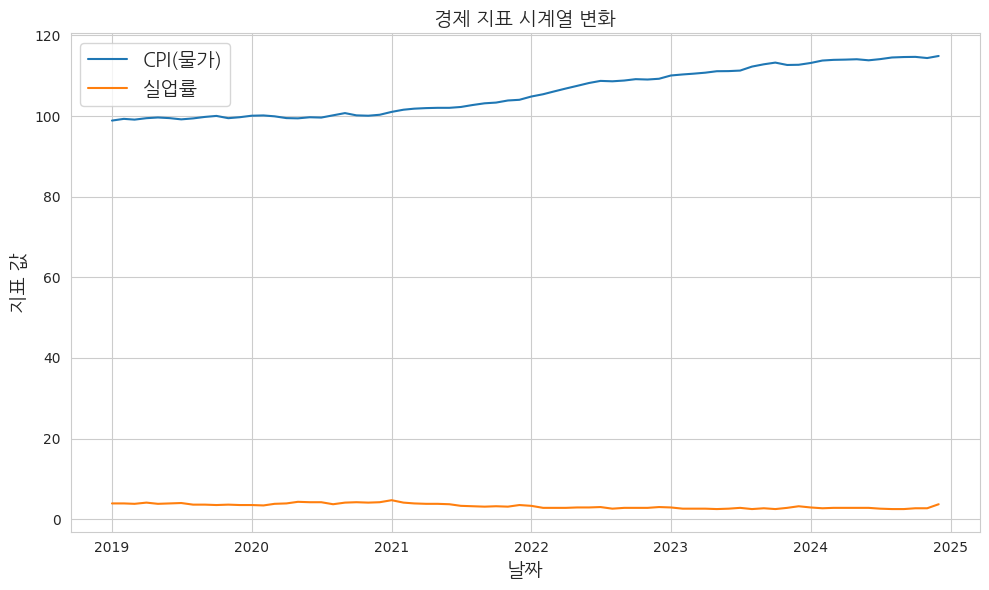

In [7]:
# graph 1: 경제 지표 시계열 (CPI, 실업률)

plt.figure(figsize=(10, 6))

if "CPI" in merged.columns:
    plt.plot(merged["date"], merged["CPI"], label="CPI(물가)")

if "실업률" in merged.columns:
    plt.plot(merged["date"], merged["실업률"], label="실업률")

plt.title("경제 지표 시계열 변화", fontproperties=font_prop)
plt.xlabel("날짜", fontproperties=font_prop)
plt.ylabel("지표 값", fontproperties=font_prop)
plt.legend(prop=font_prop)
plt.tight_layout()
plt.show()


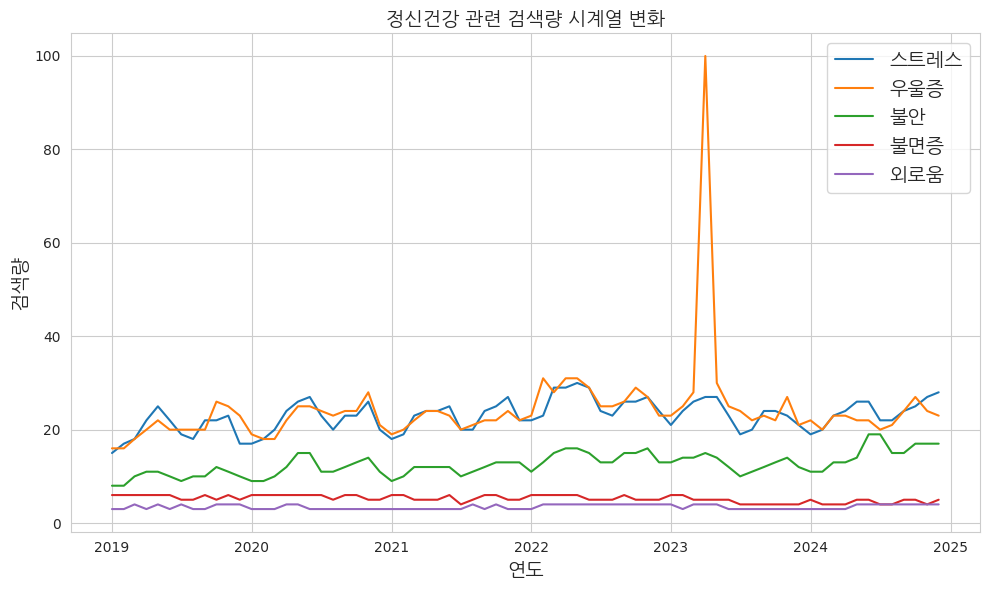

In [8]:
# graph 2: 정신건강 키워드 시계열

plt.figure(figsize=(10, 6))

for col in ["스트레스", "우울증", "불안", "불면증", "외로움"]:
    if col in merged.columns:
        plt.plot(merged["date"], merged[col], label=col)

plt.title("정신건강 관련 검색량 시계열 변화", fontproperties=font_prop)
plt.xlabel("연도", fontproperties=font_prop)
plt.ylabel("검색량", fontproperties=font_prop)
plt.legend(prop=font_prop)
plt.tight_layout()
plt.show()


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 50629 (\N{HANGUL SYLLABLE EOB}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 47456 (\N{HANGUL SYLLABLE RYUL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 47112 (\N{HANGUL SYLLABLE RE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr

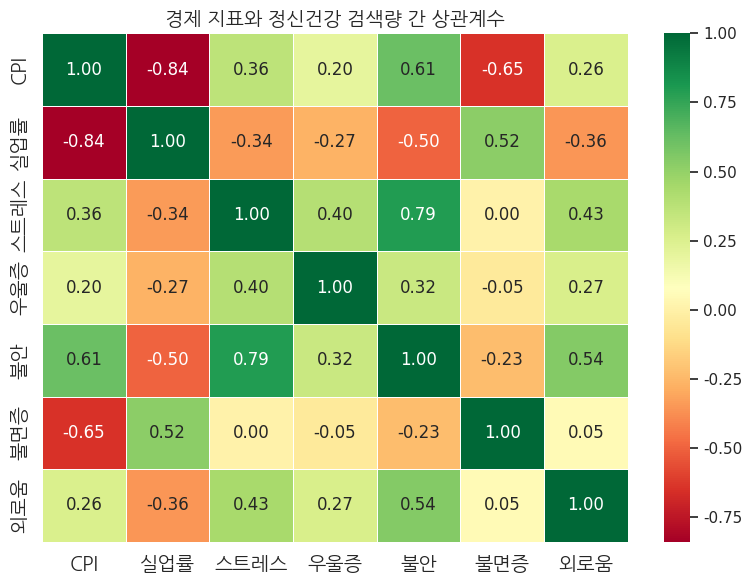

In [9]:
# graph 3: 경제 지표 & 정신건강 검색어 상관계수 히트맵

sns.set(rc={'figure.figsize': (8, 6)})

corr_cols = [c for c in ["CPI", "실업률", "스트레스", "우울증", "불안", "불면증", "외로움"]
             if c in merged.columns]

corr = merged[corr_cols].corr()

ax = sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn", linewidths=.5)
plt.title("경제 지표와 정신건강 검색량 간 상관계수", fontproperties=font_prop)

ax.set_xticklabels(ax.get_xticklabels(), fontproperties=font_prop)
ax.set_yticklabels(ax.get_yticklabels(), fontproperties=font_prop)

plt.tight_layout()
plt.show()


## 연도별 Plotly Animation

연도별 평균값을 사용해서

- x축: 연도
- y축: 정신건강 검색량
- size: CPI
  
연도별로 정신건강 검색량과 물가 수준이 어떻게 변하는지 직관적으로 볼 수 있다.

In [10]:
import plotly.express as px

anim_df = merged.copy()
anim_df["연도"] = anim_df["date"].dt.year

mental_candidates = ["스트레스", "우울증", "불안", "불면증", "외로움"]
mental_cols = [c for c in mental_candidates if c in anim_df.columns]
print("사용하는 정신건강 컬럼:", mental_cols)

agg_cols = ["실업률", "CPI"] + mental_cols
year_mean = anim_df.groupby("연도", as_index=False)[agg_cols].mean()
year_mean.head()

# long 형태로 변환해서 Plotly에 사용

long_year = year_mean.melt(
    id_vars=["연도", "CPI"],
    value_vars=mental_cols,
    var_name="지표",
    value_name="검색량"
)
long_year.head()


사용하는 정신건강 컬럼: ['스트레스', '우울증', '불안', '불면증', '외로움']


,연도,CPI,지표,검색량
0,2019,99.465583,스트레스,20.000000
1,2020,100.000000,스트레스,22.250000
2,2021,102.498333,스트레스,22.583333
3,2022,107.715000,스트레스,26.000000
4,2023,111.590000,스트레스,23.250000


In [ ]:
# 애니메이션 산점도

x_min = long_year["연도"].min() - 1
x_max = long_year["연도"].max() + 1
y_min = long_year["검색량"].min() - 5
y_max = long_year["검색량"].max() + 5

fig = px.scatter(
    long_year,
    x="연도",
    y="검색량",
    color="지표",
    size="CPI",
    hover_name="지표",
    animation_frame="연도",
    animation_group="지표",
    size_max=35,
    range_x=[x_min, x_max],
    range_y=[y_min, y_max],
    title="연도별 정신건강 검색량과 물가(CPI)"
)

fig.update_layout(
    width=900,
    height=700,
    legend_title_text="정신건강 지표"
)

fig.show()
fig.write_html('/content/economic_mental_health_animation.html')


## ARIMA를 이용한 예측

- 전체 기간의 80%는 학습(train), 20%는 테스트(test)로 사용
- `ndiffs`로 차분 차수(d)를 자동으로 결정
- `auto_arima`로 (p, d, q)를 자동 탐색
- 각 지표별 RMSE를 계산해서 예측 성능을 확인했다.

그래프에서는

- 연한 실선: 학습 구간 실제값
- 점선: 테스트 구간 실제값
- 굵은 실선: 예측값



In [12]:
# ARIMA 예측을 위한 library 설치
!pip install -q pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 9.4 MB/s eta 0:00:00


In [13]:
import pmdarima as pm
from sklearn.metrics import mean_squared_error

# 정신건강 관련 지표 리스트
mental_candidates = ["스트레스", "우울증", "불안", "불면증", "외로움"]
mental_cols = [c for c in mental_candidates if c in merged.columns]

print("ARIMA 적용할 정신건강 지표:", mental_cols)

# 날짜를 인덱스로 사용
tmp = merged[["date"] + mental_cols].dropna().copy()
tmp = tmp.sort_values("date")
tmp.set_index("date", inplace=True)

# 80:20 Train/Test 분할
split_idx = int(len(tmp) * 0.8)
train = tmp.iloc[:split_idx]
test  = tmp.iloc[split_idx:]

pred_dict = {}
rmse_dict = {}

# 각 지표별로 ARIMA 모델 학습 + 예측

for col in mental_cols:
    print(f"\n>>> {col} 예측중...")

    y_train = train[col]
    y_test  = test[col]

    d = pm.arima.ndiffs(y_train, test="adf")

    # auto_arima로 (p, d, q) 탐색
    model = pm.auto_arima(
        y_train,
        d=d,
        start_p=0, max_p=2,
        start_q=0, max_q=2,
        seasonal=False,
        stepwise=True,
        error_action="ignore",
        suppress_warnings=True
    )

    # 테스트 구간 길이만큼 예측
    preds = model.predict(n_periods=len(y_test))
    pred_dict[col] = preds

    # RMSE 계산
    rmse = (mean_squared_error(y_test, preds)) ** 0.5
    rmse_dict[col] = rmse
    print(f"{col} RMSE = {rmse:.4f}")

ARIMA 적용할 정신건강 지표: ['스트레스', '우울증', '불안', '불면증', '외로움']

>>> 스트레스 예측중...
스트레스 RMSE = 2.5033

>>> 우울증 예측중...
우울증 RMSE = 2.7953

>>> 불안 예측중...
불안 RMSE = 3.6878

>>> 불면증 예측중...
불면증 RMSE = 0.4901

>>> 외로움 예측중...
외로움 RMSE = 0.5976


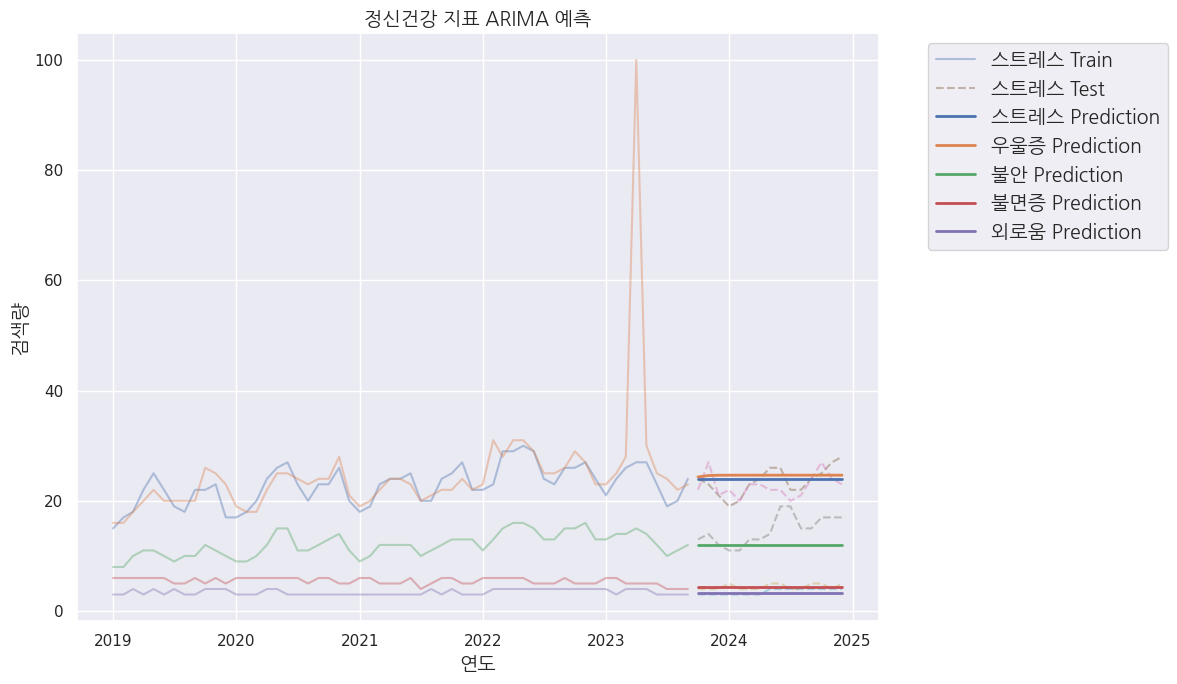

RMSE 결과: {'스트레스': 2.503331114069145, '우울증': 2.7953093150046273, '불안': 3.687817782917155, '불면증': 0.4901213491836621, '외로움': 0.597635711455492}


In [14]:
# 전체 예측 결과

plt.figure(figsize=(12, 7))

# Train (연한 선)
for col in mental_cols:
    plt.plot(train.index, train[col], alpha=0.4,
             label=f"{col} Train" if col == mental_cols[0] else None)

# Test (점선)
for col in mental_cols:
    plt.plot(test.index, test[col], alpha=0.5, linestyle="--",
             label=f"{col} Test" if col == mental_cols[0] else None)

# Prediction (굵은 선)
for col in mental_cols:
    plt.plot(test.index, pred_dict[col], linewidth=2, label=f"{col} Prediction")

plt.title("정신건강 지표 ARIMA 예측", fontproperties=font_prop)
plt.xlabel("연도", fontproperties=font_prop)
plt.ylabel("검색량", fontproperties=font_prop)
plt.legend(prop=font_prop, bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

print("RMSE 결과:", rmse_dict)
